# SVM Model Evaluation Notebook

This notebook evaluates the trained SVM model using confusion matrix and SHAP analysis.

In [ ]:
import sys
sys.path.append('../src')

In [ ]:
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from data_processing_SVM import load_data

In [ ]:
# Load the trained SVM model
model = joblib.load('../models/svm_model.pkl')

# Load the test data
X_train, X_test, y_train, y_test = load_data()

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       161
           1       0.62      0.45      0.53        11

    accuracy                           0.95       172
   macro avg       0.79      0.72      0.75       172
weighted avg       0.94      0.95      0.94       172



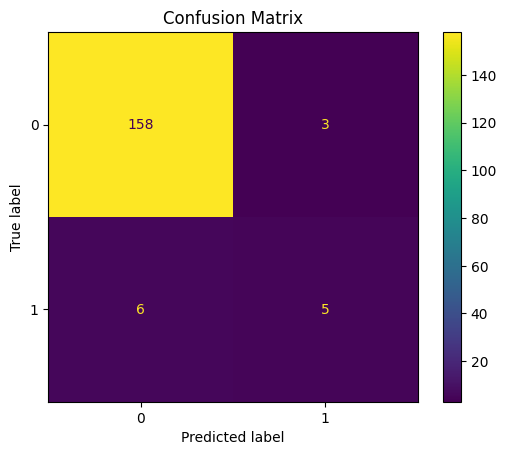

In [ ]:
# Evaluate the model
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
  2%|▏         | 1/50 [00:02<01:51,  2.27s/it]c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  war

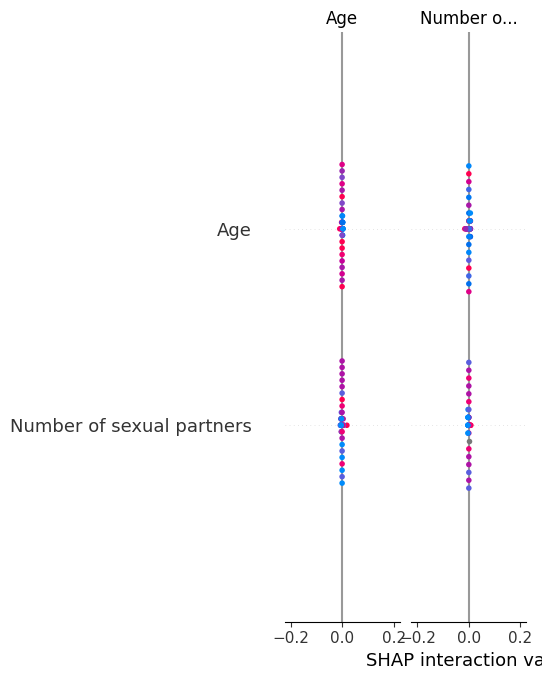

In [ ]:
# SHAP Analysis
def predict_proba(X):
    return model.predict_proba(X)

explainer = shap.KernelExplainer(predict_proba, shap.sample(X_train, 100), keep_index=False)
shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(shap_values, X_test[:50])